# 05.32 - End-to-End Classification Project

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Apply everything learned to a complete classification pipeline from raw data to production-ready model.

## 2. Why Does This Matter?

Real ML projects require end-to-end thinking: data -> preprocessing -> model -> evaluation -> deployment.

## 3. Prerequisites

- All previous notebooks

## 4. Learning Objectives

- Build a complete ML pipeline
- Handle missing values, encoding, scaling
- Compare multiple models
- Evaluate properly with CV
- Save the final model

## 5. Mental Model

End-to-end = reproducible pipeline that transforms raw data into predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib, warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Load and Explore Data

In [2]:
titanic = sns.load_dataset("titanic")
print("Shape:", titanic.shape)
print("")
print("Missing values:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])
print("")
print("Target distribution:")
print(titanic["survived"].value_counts())

Shape: (891, 15)

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64


## 7. Feature Engineering

In [3]:
df = titanic.copy()

df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)
df["fare_bin"] = pd.qcut(df["fare"], 4, labels=False)
df["age_bin"] = pd.cut(df["age"], bins=[0, 12, 18, 35, 60, 100], labels=False)

features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked",
            "family_size", "is_alone", "fare_bin", "age_bin"]
target = "survived"

df_clean = df[features + [target]].dropna()
X = df_clean[features]
y = df_clean[target]

print("Clean data shape:", X.shape)

Clean data shape: (712, 11)


## 8. Build Pipeline

In [4]:
num_features = ["age", "sibsp", "parch", "fare", "family_size", "fare_bin", "age_bin"]
cat_features = ["pclass", "sex", "embarked", "is_alone"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), cat_features)
])

print("Preprocessor created.")

Preprocessor created.


## 9. Model Comparison

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "GB": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5)
    print(name + ": " + str(round(scores.mean(), 4)) + " (+/- " + str(round(scores.std(), 4)) + ")")

LR: 0.7926 (+/- 0.0251)


RF: 0.7838 (+/- 0.0329)


GB: 0.8207 (+/- 0.0223)


## 10. Tune Best Model

In [6]:
pipe = Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(random_state=42))])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV accuracy: 0.8295


## 11. Final Evaluation

In [7]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("")
print("Classification report:")
print(classification_report(y_test, y_pred))

Test accuracy: 0.7832

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        85
           1       0.73      0.74      0.74        58

    accuracy                           0.78       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.78      0.78      0.78       143



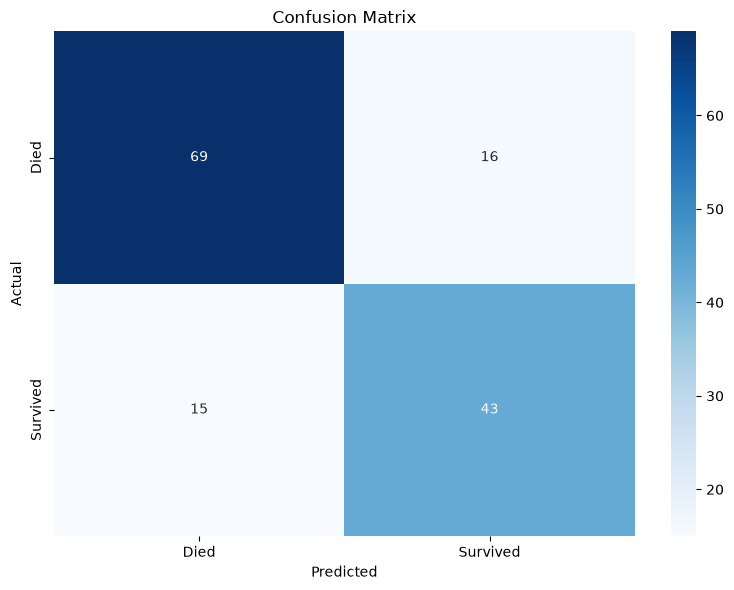

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("final_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

## 12. Save Model

In [9]:
save_path = r"D:\CODE\complete ml\models\titanic_best.joblib"
import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(best_model, save_path)
print("Model saved to:", save_path)

Model saved to: D:\CODE\complete ml\models\titanic_best.joblib


## 13. Summary

End-to-end: explore -> engineer features -> build pipeline -> compare models -> tune -> evaluate -> save. Always use Pipeline. Evaluate with CV. Save the complete pipeline.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, seaborn, scikit-learn, joblib]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```